# 3. Basic Plotting
By the end of this lesson, students will be able to:

- Obtain and interpret preliminary information about a pandas.DataFrame using methods such as info() (structure), describe() (summary statistics), nunique() (unique value counts), unique() (distinct values), and value_counts() (frequency counts)
- Create simple exploratory plots using the plot() method for pandas.DataFrames to visualize trends and distributions
- Understand the concept of performing operations on a pandas.DataFrame in-place
- Apply method chaining to enable concise and readable code


## SONGS data

In [115]:
import pandas as pd

# Read in file
df = pd.read_csv('data/wetlands_seasonal_bird_diversity.csv')

# Check the first 5 rows
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


## Line plots with plot() method


We can make a line plot of one column against another by using the following general syntax:

`df.plot(x='x_values_column', y='y_values_column')`

<Axes: xlabel='year'>

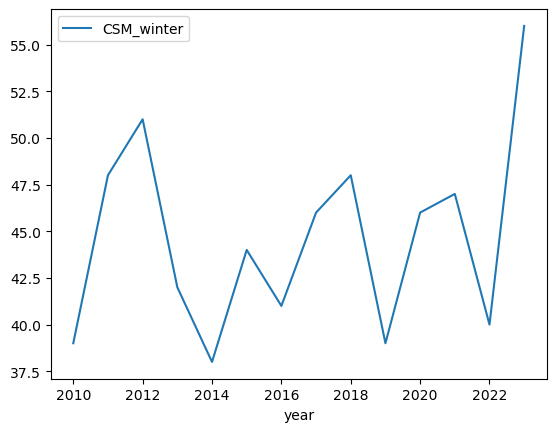

In [116]:
# Bird species registered during winter at CSM yearly
df.plot(x='year', y='CSM_winter')

We can do some basic customization specifying other parameters of the plot() method. Some basic ones are:

**title**: title to use for the plot.

**xlabel**: name to use for the x-label on x-axis

**ylabel**: name to use for the y-label on y-axis

**color**: change the color of our plot

**legend**: boolean value True or False. True (default) includes the legend, False removes the legend

plot() documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html 

<Axes: title={'center': 'Bird species registered during winter at Carpinteria Salt Marsh'}, xlabel='Year', ylabel='Number of bird species'>

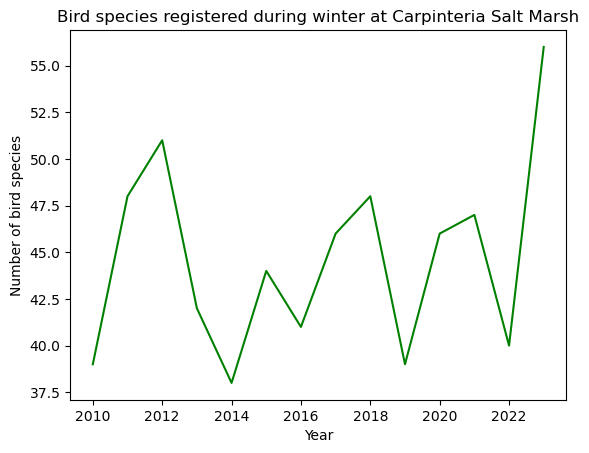

In [117]:
df.plot(x='year', 
        y='CSM_winter',
        title='Bird species registered during winter at Carpinteria Salt Marsh',
        xlabel='Year',
        ylabel='Number of bird species',
        color='green',
        legend=False
        )

### Check-in
Plot a graph of the spring bird surveys at Mugu Lagoon with respect to the years. Include some basic customization.


<Axes: title={'center': 'Bird species registered during spring at Mugu Lagoon'}, xlabel='Year', ylabel='Number of bird species'>

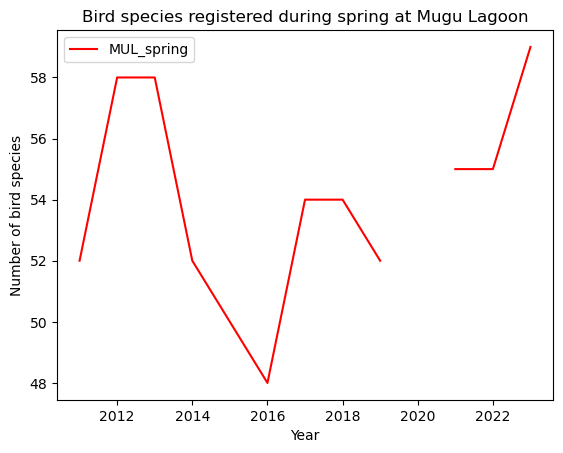

In [118]:
df.plot(x='year', 
        y='MUL_spring',
        title='Bird species registered during spring at Mugu Lagoon',
        xlabel='Year',
        ylabel='Number of bird species',
        color='red',
        legend=True
        )


Use the isna() method for pandas.Series and row selection to select the rows in which Mugu Lagoon has NAs during the spring survey.

In [119]:
## Come back to this

mul_spring = df['MUL_spring'].isna()
# mul_spring['MUL_spring']

## Multiple line plots


We can plot multiple line plots by updating these parameters in the plot() method:

y : a list of column names that will be plotted against the x-axis

color: a dictionary {'column_1' : 'color_1', 'column_2':'color_2'} specifying the color of each column’s line plot

<Axes: title={'center': 'Seasonal bird surveys at Tijuana Estuary'}, xlabel='Year', ylabel='Number of bird species'>

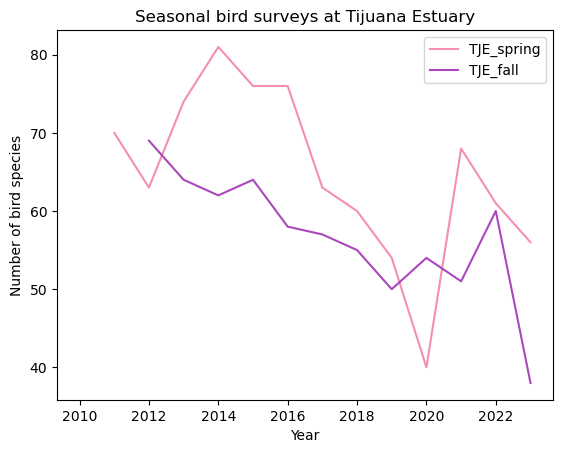

In [120]:
# Ex. Let’s say we want to compare the bird surveys at the Tijuana Estuary during spring and fall across years.
df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                 }
        )

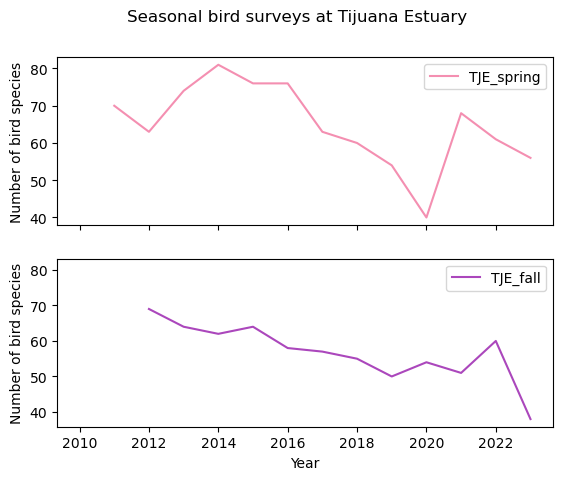

In [121]:
# Subplots parameter creates multiple different plots

df.plot(x='year', 
        y=['TJE_spring', 'TJE_fall'],
        title = 'Seasonal bird surveys at Tijuana Estuary',
        xlabel='Year',
        ylabel='Number of bird species',        
        color = {'TJE_spring':'#F48FB1',
                 'TJE_fall': '#AB47BC'
                 },
        subplots=True
        );

## Updating the index

To update the index we use the set_index():

`df = df.set_index(new_index)`

Where new_index is:

- the *name of the column* in the data frame df we want to use as new index
- if our new index is not a column in the data frame, an *array* or pandas.Series of the same length as our data frame (we need one index per row).

This operation does not happen in-place.

A function **acting in-place** means that our original object (in this case a pandas.DataFrame) is modified.
If the function **does not act in-place**, a new object (in this case a pandas.DataFrame) is created and the original is not modified.

If we wanted to update our df data frame we could do an **explicit assignment** to reassign the output of set_index() to df:

In [122]:
# Set `column_name` column in df as the new index (reassignment)
# df = df.set_index('column_name') # optional inplace= parameter

In [123]:
# Update the index to be the year column
df = df.set_index('year')
df.head()

,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
year,,,,,,,,,,,,
2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


<Axes: xlabel='year'>

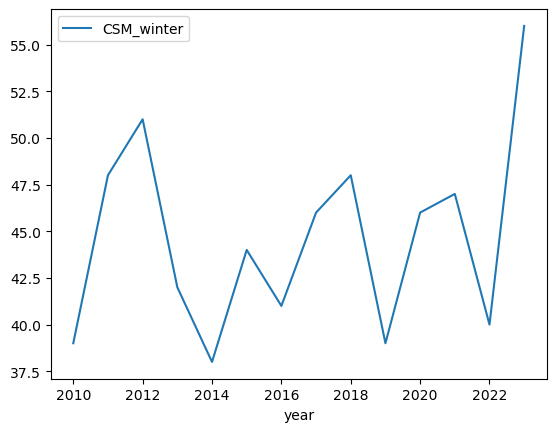

In [124]:
# Simple plot of Carpinteria Salt Marsh winter surveys
df.plot(y='CSM_winter')

In [125]:
# If needed, we can reset the index to be the numbering of the rows:
df = df.reset_index()
df.head()

,year,CSM_winter,CSM_spring,CSM_fall,MUL_winter,MUL_spring,MUL_fall,SDW_winter,SDW_spring,SDW_fall,TJE_winter,TJE_spring,TJE_fall
0,2010,39.0,40.0,50.0,45.0,NaN,61.0,NaN,75.0,85.0,NaN,NaN,81.0
1,2011,48.0,44.0,NaN,58.0,52.0,NaN,78.0,74.0,NaN,67.0,70.0,NaN
2,2012,51.0,43.0,49.0,57.0,58.0,53.0,71.0,72.0,73.0,70.0,63.0,69.0
3,2013,42.0,46.0,38.0,60.0,58.0,62.0,69.0,70.0,70.0,69.0,74.0,64.0
4,2014,38.0,43.0,45.0,49.0,52.0,57.0,61.0,78.0,71.0,60.0,81.0,62.0


`df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()`

1. This code is plotting a df filtered by columns between SDW_winter and TJE_fall in wich the index is year. The resulting plot likely shows column values on the y-axis and year on the x-axis.
2. This code is modifying the dataframe by resetting the index and filtering the columns BUT only temporarily. It is not copying this new df or assigning it to a new variable.
3. Run the code: Do we have all the necessary information to make sure it makes sense to directly compare the surveys at these different sites?
    *Not neccessarily. We don't know if the same sampling methods were used at different sites. However, given they were conducted by the same company, it's highly likely sampling was standardized.*

<Axes: xlabel='year'>

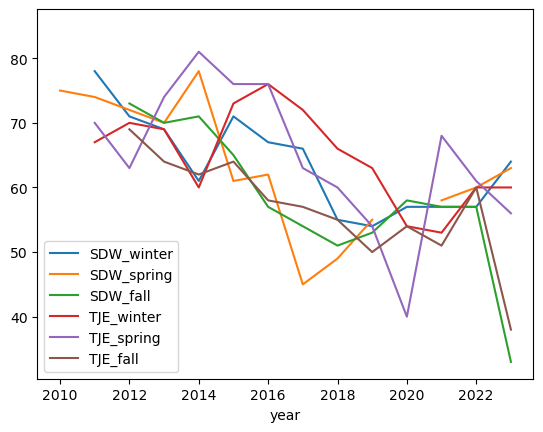

In [126]:
df.set_index('year').loc[:,'SDW_winter':'TJE_fall'].plot()

## Method chaining


**Method chaining and the R pipe operator**

If you are familiar with R, you may have noticed that the period `.` in the method chaining plays a similar role to the R pipe operator `(%>% or |>)`. They are not the same, though: the R pipe passes the result on the left as the first argument of any function, while the period can only call methods that belong to the object on the left.

The syntax of one method per line is similar to what is used in the tidyverse, except that the pipe is used at the end of the line, while the period is used at the beginning of the line.

**Use method chaining wisely**

Method chaining is particularly useful in pandas for streamlining multiple data manipulations. However:

method chaining should be used with care to avoid overly complex and difficult-to-debug code, and
if you’re not familiar with the methods, it’s better to apply them individually and review the results after each step.

## Data exploration: palmerpenguins

In [127]:
# Read in data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [128]:
# Number of values per unique value in species column
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## `kind` arguement in `plot()`

Parameters
data : Series or DataFrame The object for which the method is called. x : label or position, default None Only used if data is a DataFrame. y : label, position or list of label, positions, default None Allows plotting of one column versus another. Only used if data is a DataFrame. 

kind : str 

The kind of plot to produce:

- 'line' : line plot (default)
- 'bar' : vertical bar plot
- 'barh' : horizontal bar plot
- 'hist' : histogram
- 'box' : boxplot
- 'kde' : Kernel Density Estimation plot
- 'density' : same as 'kde'
- 'area' : area plot
- 'pie' : pie plot
- 'scatter' : scatter plot (DataFrame only)
- 'hexbin' : hexbin plot (DataFrame only)

### Scatterplots

<Axes: title={'center': 'Flipper length and body mass for Palmer penguins'}, xlabel='Flipper length (mm)', ylabel='Body mass (g)'>

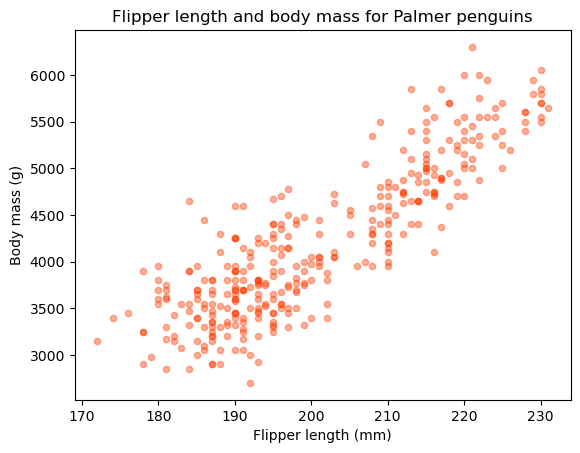

In [129]:
penguins.plot(kind='scatter',
              x='flipper_length_mm', 
              y='body_mass_g',
              title='Flipper length and body mass for Palmer penguins',
              xlabel='Flipper length (mm)',
              ylabel='Body mass (g)',
              color='#ff3b01',
              alpha=0.4  # Controls transparency
              )

### Bar plots

<Axes: >

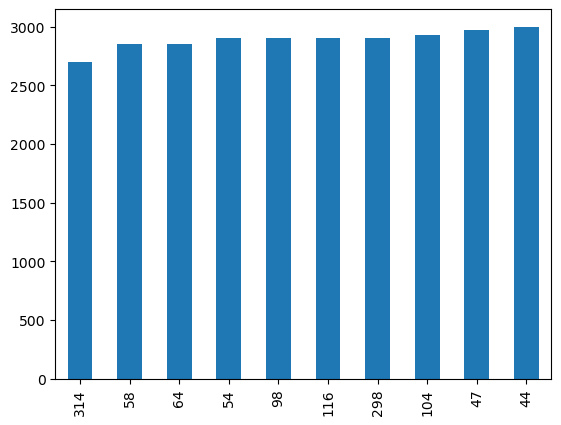

In [130]:
smallest = penguins['body_mass_g'].nsmallest(10)
smallest.plot(kind='bar')

In [131]:
# If we wanted to look at other data for these smallest penguins we can use a different call to the nsmallest method:
penguins.nsmallest(10, 'body_mass_g')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
314,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,female,2008
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,female,2008
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,female,2008
98,Adelie,Dream,33.1,16.1,178.0,2900.0,female,2008
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,female,2009
298,Chinstrap,Dream,43.2,16.6,187.0,2900.0,female,2007
104,Adelie,Biscoe,37.9,18.6,193.0,2925.0,female,2009
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
44,Adelie,Dream,37.0,16.9,185.0,3000.0,female,2007


### Histograms

<Axes: title={'center': 'Penguin flipper lengths'}, xlabel='Flipper length (mm)', ylabel='Frequency'>

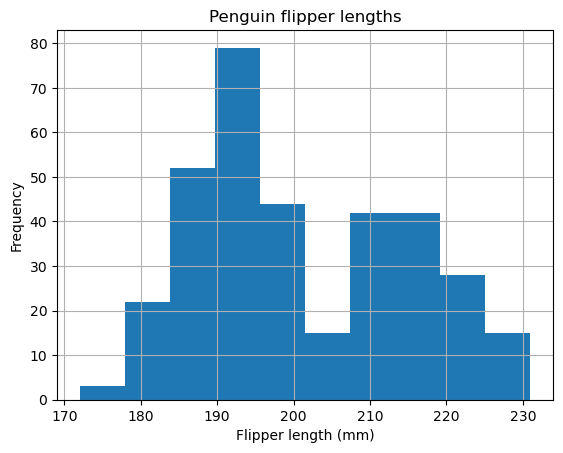

In [132]:
# Distribution of flipper length measurements
# First select data, then plot
penguins['flipper_length_mm'].plot(kind='hist',
                                title='Penguin flipper lengths',
                                xlabel='Flipper length (mm)',
                                grid=True)

#### Check-in
1. Select the bill_length_mm and bill_depth_mm columns in the penguins data frame and then update the kind parameter to box to make boxplots of the bill length and bill depth.


<Axes: title={'center': 'Box Plot of Bill Length and Depth'}, ylabel='Millimeters'>

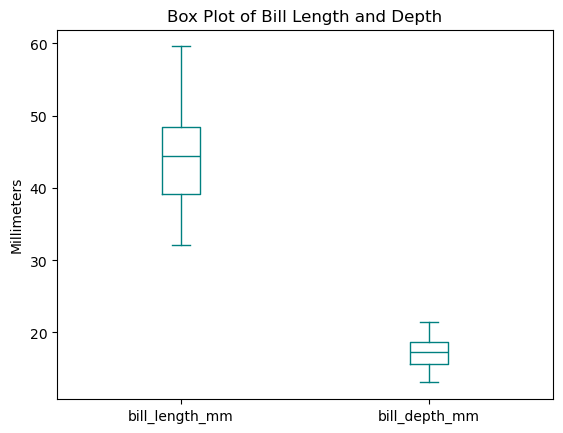

In [136]:
penguins.loc[:, 'bill_length_mm':'bill_depth_mm'].plot(
    kind= 'box',
    title = "Box Plot of Bill Length and Depth",
    ylabel = 'Millimeters',
    color = 'teal'
)

2. Create a simple histogram of the flipper length of female gentoo penguins.

<Axes: title={'center': 'Flipper Length of Female Penguins'}, ylabel='Frequency'>

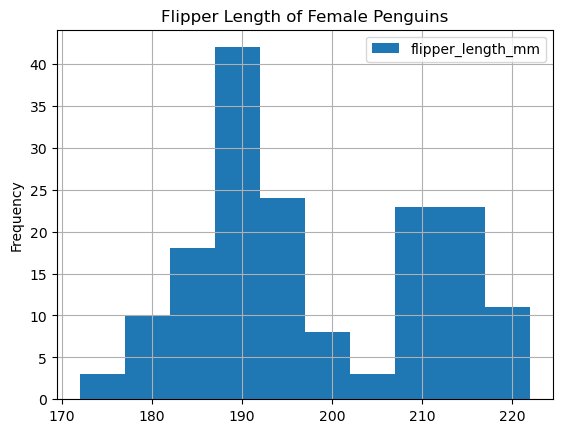

In [ ]:
female = penguins[penguins['sex'] == 'female']
female[['species', 'flipper_length_mm', 'sex']].plot(
    kind = 'hist',
    title = 'Flipper Length of Female Penguins',
    grid = True
)
## How do I color it by species ??